In [ ]:
# Add Characters


In [1]:
import sqlite3
import pandas as pd
import unicodedata
df = pd.read_csv(
    r"C:\Users\colta\OneDrive\デスクトップ\Unihan Project\Unihan\Unihan_Readings.txt",
    sep="\t",
    comment="#",
    names=["codepoint", "field", "value"],
    encoding="utf-8"
)


df.head()


,codepoint,field,value
0,U+3400,kCantonese,jau1
1,U+3400,kDefinition,(same as 丘) hillock or mound
2,U+3400,kJapanese,キュウ おか
3,U+3400,kMandarin,qiū
4,U+3401,kDefinition,"to lick; to taste, a mat, bamboo bark"


In [2]:
df['field'].unique()

array(['kCantonese', 'kDefinition', 'kJapanese', 'kMandarin', 'kFanqie',
       'kHanyuPinyin', 'kTGHZ2013', 'kXHC1983', 'kVietnamese',
       'kSMSZD2003Readings', 'kHangul', 'kTang', 'kJapaneseKun',
       'kJapaneseOn', 'kHanyuPinlu', 'kKorean', 'kZhuang'], dtype=object)

In [3]:
#Show Characters 漢字
# define function and add column
def codepoint_to_char(cp):
    return chr(int(cp.replace("U+", ""), 16))
# add column/ apply function
df["char"] = df["codepoint"].apply(codepoint_to_char)
df.tail()
    

,codepoint,field,value,char
291222,U+3237F,kMandarin,yè,𲍿
291223,U+32385,kMandarin,chì,𲎅
291224,U+32386,kMandarin,tóng,𲎆
291225,U+32388,kMandarin,méng,𲎈
291226,U+32389,kMandarin,mò,𲎉


In [4]:
# ANy Nans
df.isna().sum()

codepoint     0
field         0
value        22
char          0
dtype: int64

In [5]:
len(df)

291227

In [6]:
# Clac % of NaNs later
#(df['value'].isna().sum()) \ (len(df)) 

In [7]:

df[df['value'].isna()]['field'].value_counts()

kKorean         19
kVietnamese      2
kJapaneseKun     1
Name: field, dtype: int64

In [8]:
#Take types of fields and gives them their own columns (I think?!?!)
df_wide = df.pivot(index='codepoint', columns='field', values='value')
df_wide.isna().sum()

field
kCantonese            37980
kDefinition           44631
kFanqie               47694
kHangul               59391
kHanyuPinlu           64117
kHanyuPinyin          33786
kJapanese             16333
kJapaneseKun          56621
kJapaneseOn           54739
kKorean               58885
kMandarin             23568
kSMSZD2003Readings    59806
kTGHZ2013             59811
kTang                 64105
kVietnamese           59612
kXHC1983              56844
kZhuang               65444
dtype: int64

In [9]:
df_wide

field,kCantonese,kDefinition,kFanqie,kHangul,kHanyuPinlu,kHanyuPinyin,kJapanese,kJapaneseKun,kJapaneseOn,kKorean,kMandarin,kSMSZD2003Readings,kTGHZ2013,kTang,kVietnamese,kXHC1983,kZhuang
codepoint,,,,,,,,,,,,,,,,,
U+20000,NaN,the sound made by breathing in; oh! (see ㄛ BOP...,NaN,NaN,NaN,10011.010:hē,カ,NaN,NaN,NaN,hē,NaN,NaN,NaN,NaN,NaN,NaN
U+20001,cat1,(original form of 七),NaN,NaN,NaN,NaN,シツ,NaN,NaN,NaN,qī,NaN,NaN,NaN,NaN,NaN,NaN
U+20003,NaN,NaN,NaN,NaN,NaN,"10008.010:qiě,jī",ショ キ,NaN,NaN,NaN,qiě,NaN,NaN,NaN,NaN,NaN,NaN
U+20005,hoi6,(variant of 亥),NaN,NaN,NaN,NaN,カイ,NaN,NaN,NaN,hài,NaN,NaN,NaN,NaN,NaN,NaN
U+20007,NaN,NaN,NaN,NaN,NaN,NaN,ショ,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
U+FA2B,NaN,raise animals; feed; nourish,NaN,NaN,NaN,NaN,NaN,KAU YASHINAU,SHI JI,SA,NaN,NaN,NaN,NaN,NaN,NaN,NaN
U+FA2C,NaN,public building,NaN,NaN,NaN,NaN,NaN,YAKATA TATE,KAN,KWAN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
U+FA2D,NaN,crane,NaN,NaN,NaN,NaN,NaN,TSURU,KAKU,HAK,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [10]:
#2/16/2026 I want to do without lambda 
# i see the codepoint actually is the index 
# df_wide['codepoint'] doesnt show
# so we need to add the character after the pivot
#df_wide['char'] = df_wide.index.map(lambda x: chr(int(x, 16)))
# I suck at lamba so cheat copy paste ????? lookup later


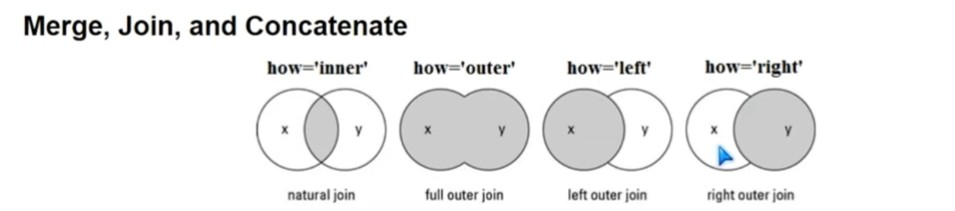

In [11]:
char_map = df[['codepoint', 'char']].drop_duplicates()
df_wide = df_wide.merge(char_map, on='codepoint', how = 'left')

In [12]:
df_wide

,codepoint,kCantonese,kDefinition,kFanqie,kHangul,kHanyuPinlu,kHanyuPinyin,kJapanese,kJapaneseKun,kJapaneseOn,kKorean,kMandarin,kSMSZD2003Readings,kTGHZ2013,kTang,kVietnamese,kXHC1983,kZhuang,char
0,U+20000,NaN,the sound made by breathing in; oh! (see ㄛ BOP...,NaN,NaN,NaN,10011.010:hē,カ,NaN,NaN,NaN,hē,NaN,NaN,NaN,NaN,NaN,NaN,𠀀
1,U+20001,cat1,(original form of 七),NaN,NaN,NaN,NaN,シツ,NaN,NaN,NaN,qī,NaN,NaN,NaN,NaN,NaN,NaN,𠀁
2,U+20003,NaN,NaN,NaN,NaN,NaN,"10008.010:qiě,jī",ショ キ,NaN,NaN,NaN,qiě,NaN,NaN,NaN,NaN,NaN,NaN,𠀃
3,U+20005,hoi6,(variant of 亥),NaN,NaN,NaN,NaN,カイ,NaN,NaN,NaN,hài,NaN,NaN,NaN,NaN,NaN,NaN,𠀅
4,U+20007,NaN,NaN,NaN,NaN,NaN,NaN,ショ,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,𠀇
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
67911,U+FA2B,NaN,raise animals; feed; nourish,NaN,NaN,NaN,NaN,NaN,KAU YASHINAU,SHI JI,SA,NaN,NaN,NaN,NaN,NaN,NaN,NaN,飼
67912,U+FA2C,NaN,public building,NaN,NaN,NaN,NaN,NaN,YAKATA TATE,KAN,KWAN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,館
67913,U+FA2D,NaN,crane,NaN,NaN,NaN,NaN,NaN,TSURU,KAKU,HAK,NaN,NaN,NaN,NaN,NaN,NaN,NaN,鶴
67914,U+FA2E,NaN,NaN,NaN,낭:0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,郞


In [13]:
# df_wide[['kJapanese', 'kVietnamese']].dropna().shape() ###typo kJapaneseOn
df_wide[['kJapaneseOn', 'kVietnamese']].dropna().shape[0]


3608

In [14]:
df_jp_viet = df_wide[['char','kJapaneseOn', 'kVietnamese']].dropna()
df_jp_viet 

,char,kJapaneseOn,kVietnamese
9838,𣏾,ZAI,qua
46656,一,ICHI ITSU,nhất
46657,丁,TEI CHOU TOU,đinh
46659,七,SHICHI SHITSU,thất
46663,万,MAN BAN,vạn
...,...,...,...
67358,點,TEN,điểm
67406,鼎,TEI,đỉnh
67466,齊,SEI ZAI SAI,tày
67474,齒,SHI,xỉ


In [15]:
df_jp_viet['kJapaneseOn'].nunique()

1359

In [16]:
df_jp_viet['kJapaneseOn'].head(20)

9838                ZAI
46656         ICHI ITSU
46657      TEI CHOU TOU
46659     SHICHI SHITSU
46663           MAN BAN
46664          JOU CHOU
46665               SAN
46666          JOU SHOU
46667             KA GE
46669    FU BU FUTSU HI
46670                YO
46672         KAI KATSU
46673          CHUU CHU
46676           SHA SHO
46677                HI
46678            SE SEI
46680              KYUU
46681          HEI HYOU
46686          SHOU JOU
46690          CHUU CHU
Name: kJapaneseOn, dtype: object

In [17]:
df_jp_viet_exploded =df_jp_viet.assign(
    kJapaneseOn=df_jp_viet['kJapaneseOn'].str.split()
).explode('kJapaneseOn')

df_jp_viet_exploded['kJapaneseOn'].nunique()

393

In [18]:
df_jp_viet_exploded

,char,kJapaneseOn,kVietnamese
9838,𣏾,ZAI,qua
46656,一,ICHI,nhất
46656,一,ITSU,nhất
46657,丁,TEI,đinh
46657,丁,CHOU,đinh
...,...,...,...
67466,齊,ZAI,tày
67466,齊,SAI,tày
67474,齒,SHI,xỉ
67533,龍,RYUU,long


In [19]:
#See if there are multiple reading for Vietnamese
df_jp_viet = df_wide[['char','kJapaneseOn','kVietnamese']].dropna()
df_viet_exploded = df_jp_viet.assign(
    kVietnamese=df_jp_viet['kVietnamese'].str.split()
).explode('kVietnamese')


In [20]:
df_viet_exploded.nunique()

char           3608
kJapaneseOn    1359
kVietnamese    2658
dtype: int64

In [21]:
df_jp_viet = df_wide[['char','kJapaneseOn','kVietnamese']].dropna()

In [22]:
df_jp_viet

,char,kJapaneseOn,kVietnamese
9838,𣏾,ZAI,qua
46656,一,ICHI ITSU,nhất
46657,丁,TEI CHOU TOU,đinh
46659,七,SHICHI SHITSU,thất
46663,万,MAN BAN,vạn
...,...,...,...
67358,點,TEN,điểm
67406,鼎,TEI,đỉnh
67466,齊,SEI ZAI SAI,tày
67474,齒,SHI,xỉ


In [23]:
df_exploded = df_jp_viet.assign(
    kJapaneseOn=df_jp_viet['kJapaneseOn'].str.split(),
    kVietnamese=df_jp_viet['kVietnamese'].str.split()
).explode('kJapaneseOn').explode('kVietnamese')
df_exploded

,char,kJapaneseOn,kVietnamese
9838,𣏾,ZAI,qua
46656,一,ICHI,nhất
46656,一,ITSU,nhất
46657,丁,TEI,đinh
46657,丁,CHOU,đinh
...,...,...,...
67466,齊,ZAI,tày
67466,齊,SAI,tày
67474,齒,SHI,xỉ
67533,龍,RYUU,long


In [24]:
df_exploded.nunique()

char           3608
kJapaneseOn     393
kVietnamese    2658
dtype: int64

In [25]:
df_exploded['kJapaneseOn'].nunique()

393

📊 Think of It This Way

If 3608 characters map into:

393 Japanese syllables
→ Average ≈ 9 characters per syllable

2658 Vietnamese syllables
→ Average ≈ 1.36 characters per syllable

That’s radically different density.

Japanese has heavy many-to-one compression.

Vietnamese is much closer to one-to-one mapping.

In [26]:
## Count Pair frequencies

correspondense = (
    df_exploded
    .groupby(['kJapaneseOn', 'kVietnamese'])
    .size()
    .reset_index(name='count')
    .sort_values('count', ascending=False)
)

In [27]:
correspondense.head(30)

,kJapaneseOn,kVietnamese,count
4956,TOU,đồng,7
4000,SHI,thị,6
722,DOU,đồng,6
3317,REI,lệ,6
3967,SHI,chỉ,6
2432,KO,hồ,6
883,FUU,phong,6
3814,SEKI,tích,6
4215,SHOU,tiêu,5
4927,TOU,đào,5


In [28]:
correspondense[correspondense['kVietnamese'] == 'đồng']

,kJapaneseOn,kVietnamese,count
4956,TOU,đồng,7
722,DOU,đồng,6
4970,TSU,đồng,1


In [29]:
df_exploded[df_exploded['kVietnamese'] == 'đồng']#tac on here I get specific column info

,char,kJapaneseOn,kVietnamese
46877,仝,DOU,đồng
47406,僮,DOU,đồng
47406,僮,TOU,đồng
48204,同,DOU,đồng
48204,同,TOU,đồng
49100,垌,TOU,đồng
49100,垌,TSU,đồng
57331,瞳,DOU,đồng
57331,瞳,TOU,đồng
58149,童,DOU,đồng


In [30]:
df_exploded[df_exploded['kVietnamese']=='đồng']['kJapaneseOn'].nunique()

3

In [31]:
# Try Dong with different tone and get less characters
#These I argue more frequently used and are the
# one I orignally thought when I first ran the search.
df_exploded[df_exploded['kVietnamese']=='đông']

,char,kJapaneseOn,kVietnamese
47596,冬,TOU,đông
47629,凍,TOU,đông
53169,東,TOU,đông


In [32]:
# Reverse search what Viet maps to Japanese DOU
df_exploded[df_exploded['kJapaneseOn'] == 'DOU']['kVietnamese'].nunique()


30

In [33]:
df_exploded[df_exploded['kJapaneseOn'] == 'TOU']['kVietnamese'].nunique()

86

In [34]:
df_exploded[df_exploded['kJapaneseOn'] == 'TSU']['kVietnamese'].nunique()


12

In [35]:
df_exploded[df_exploded['kJapaneseOn'] == 'TOU']['kVietnamese']


46657     đinh
47121     dõng
47168    trành
47186      đảo
47192    thẳng
         ...  
66405      đấu
66406      đấu
66407      náo
66410      đấu
66413      đấu
Name: kVietnamese, Length: 121, dtype: object

In [36]:
#How many variations are the per each Japanese sound??
jp_diversity = (
    df_exploded
    .groupby('kJapaneseOn')['kVietnamese']
    .nunique()
    .sort_values(ascending=False)
)
jp_diversity
#KOU appears to make the most

kJapaneseOn
KOU      126
SHOU     101
TOU       86
KYOU      85
SOU       76
        ... 
TOCHI      1
JUCHI      1
BUKU       1
DOCHI      1
KYA        1
Name: kVietnamese, Length: 393, dtype: int64

In [37]:
# 客さん　khách　
df_exploded[df_exploded['kJapaneseOn'] == 'KYAKU']

,char,kJapaneseOn,kVietnamese
47894,勖,KYAKU,húc
48059,卻,KYAKU,khước
50146,客,KYAKU,khách
53372,格,KYAKU,cách
54952,湨,KYAKU,xố
61202,蛒,KYAKU,cắc
62292,謔,KYAKU,hước
63163,蹻,KYAKU,kều
64187,鉻,KYAKU,lạc
65241,隙,KYAKU,khích


In [38]:
jp_diversity[['KOU','SHOU','TOU']]

kJapaneseOn
KOU     126
SHOU    101
TOU      86
Name: kVietnamese, dtype: int64

🧠 What This Really Means

Japanese -OU syllables are collapse zones.

They are acting like phonological black holes.

Many distinct Middle Chinese syllables
→ collapsed into a small set of Japanese long-O syllables.

Vietnamese did not collapse those distinctions nearly as aggressively.

🔥 Why -OU Specifically?

Historically:

Many Middle Chinese finals like:

-ang

-ong

-uang

-ok

-uk

-ak

tone distinctions

Got flattened into long -ō sounds in Japanese.

Make Graphic for this ！！！！！！！！！！！！
công
cống
cộng
cung
cục
cốc
...May collapse into something like:　KOU

In [39]:
 Now Here's the REALLY Interesting Question

Let’s flip perspective.

We saw Japanese compresses heavily.

Now:

Which Vietnamese syllables map to the most Japanese syllables?

Run:

SyntaxError: invalid syntax (Temp/ipykernel_27096/2144396155.py, line 1)

In [40]:
vn_diversity = (
    df_exploded
    .groupby('kVietnamese')['kJapaneseOn']
    .nunique()
    .sort_values(ascending=False)
)

vn_diversity.head(10)

kVietnamese
nối      10
chót      9
kham      8
chuối     8
thích     8
dâu       7
giá       7
phất      7
khoét     7
oẹ        7
Name: kJapaneseOn, dtype: int64

In [41]:
#Get the averages not the top end
jp_diversity.mean(),vn_diversity.mean()



(13.363867684478372, 1.9759217456734386)

In [42]:
vn_diversity.mean()

1.9759217456734386

In [ ]:
#Save to Csv

In [43]:
jp_diversity.to_csv("jp_diversity.csv")
vn_diversity.to_csv("vn_diversity.csv")


In [64]:
df_exploded_alphabet= df_exploded.sort_values(by ='kJapaneseOn')
df_exploded_alphabet

,char,kJapaneseOn,kVietnamese
46699,丫,A,a
49656,妸,A,ả
49837,婭,A,ả
65285,雅,A,nhã
48522,啊,A,à
...,...,...,...
51508,惴,ZUI,nhoai
59064,繸,ZUI,choại
63618,遂,ZUI,toại
60811,蕋,ZUI,nhị


In [65]:
df_exploded.to_csv("df_exploded_alphabet", index=False)


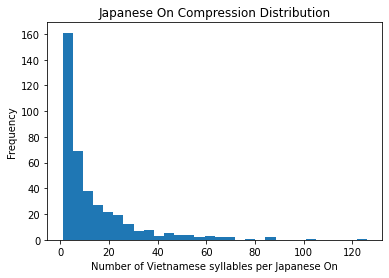

In [45]:
import matplotlib.pyplot as plt

plt.figure()
plt.hist(jp_diversity, bins=30)
plt.xlabel("Number of Vietnamese syllables per Japanese On")
plt.ylabel("Frequency")
plt.title("Japanese On Compression Distribution")
plt.show()

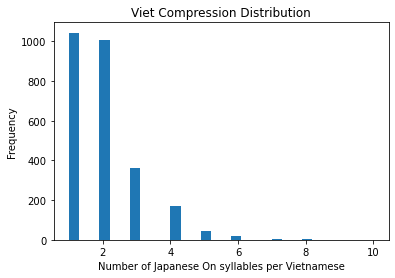

In [46]:
plt.figure()
plt.hist(vn_diversity, bins=30)
plt.xlabel("Number of Japanese On syllables per Vietnamese")
plt.ylabel("Frequency")
plt.title("Viet Compression Distribution")
plt.show()

In [52]:
max(jp_diversity)
min(jp_diversity)

1

In [50]:
sorted(jp_diversity)[-10:]


[61, 64, 65, 68, 69, 76, 85, 86, 101, 126]

In [57]:
import numpy as np
#np.mean(jp_diversity)
np.median(jp_diversity)


8.0

In [58]:
import numpy as np
np.percentile(jp_diversity, [50, 75, 90, 95, 99])


array([ 8.  , 17.  , 34.  , 48.  , 76.72])